# 機械学習コンペで人気のLightGBMをPythonで使ってみた

https://watlab-blog.com/2020/04/12/light-gbm/

[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.000000
[LightGBM] [Info] Total Bins 85
[LightGBM] [Info] Number of data points in the train set: 105, number of used features: 4
[LightGBM] [Info] Start training from score -1.127600
[LightGBM] [Info] Start training from score -1.188224
[LightGBM] [Info] Start training from score -0.990399
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 2 and depth = 1
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 3 and depth = 2
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 4 and depth = 3
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 4 and depth = 3
[LightGBM] [Warning] N

/Users/keetane/opt/anaconda3/envs/code/lib/python3.12/site-packages/lightgbm/engine.py:204: UserWarning: Found `num_iteration` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


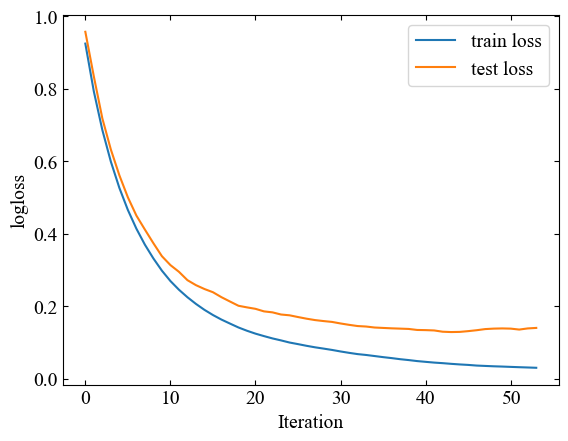

In [187]:
import lightgbm as lgb
from sklearn import datasets
from sklearn.model_selection import train_test_split
import pandas as pd
from matplotlib import pyplot as plt

# データを用意する
iris = datasets.load_iris()
X = pd.DataFrame(iris.data[:, [0, 1, 2, 3]]) 
Y = pd.Series(iris.target)

# データをホールドアウト法で分割
train_X, test_X, train_Y, test_Y = train_test_split(
    X, Y,
    test_size=0.3,
    shuffle=True,
    random_state=0
)

# データセットを登録
lgb_train = lgb.Dataset(train_X, label=train_Y)
lgb_test = lgb.Dataset(test_X, label=test_Y, reference=lgb_train)

# LightGBMのハイパーパラメータを設定
params = {
    'task': 'train',
    'boosting_type': 'gbdt',
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': 3,
    'learning_rate': 0.1,
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'num_iteration': 100,
    'force_row_wise': True
}

# Early stopping のコールバックを設定
callbacks = [lgb.early_stopping(stopping_rounds=10)]

# 学習の履歴を保存するための変数
evals_result = {}

# Early stopping のコールバックを設定 
callbacks = [lgb.early_stopping(stopping_rounds=10), lgb.record_evaluation(evals_result)]

# LightGBMのモデルを訓練する
model = lgb.train(
    params=params,
    train_set=lgb_train,
    valid_sets=[lgb_train, lgb_test],
    valid_names=['Train', 'Test'],
    num_boost_round=100,
    callbacks=callbacks,
    # evals_result=evals_result
)

# 訓練誤差と汎化誤差
loss_train = evals_result['Train']['multi_logloss']
loss_test = evals_result['Test']['multi_logloss']

# 最良の予測器が得られたイテレーション数
best_iteration = model.best_iteration
print(best_iteration)

# グラフ描画
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

fig = plt.figure()
ax1 = fig.add_subplot(111)

ax1.yaxis.set_ticks_position('both')
ax1.xaxis.set_ticks_position('both')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('logloss')

ax1.plot(loss_train, label='train loss')
ax1.plot(loss_test, label='test loss')

plt.legend()
plt.show()
plt.close()


https://watlab-blog.com/2020/04/12/light-gbm/

In [188]:
import lightgbm as lgb
from sklearn import datasets
from sklearn.model_selection import train_test_split
import pandas as pd
from matplotlib import pyplot as plt
# データを用意する
iris = datasets.load_iris()                   # scikit-learnのdatasetsを読み込む
X = pd.DataFrame(iris.data[:, [0, 1, 2, 3]])  # 訓練データ
Y = pd.Series(iris.target)                    # 教師データ

In [189]:
# データをホールドアウト法で分割
train_X, test_X, train_Y, test_Y = train_test_split(X, Y,                # 訓練データとテストデータに分割する
                                                    test_size=0.3,       # テストデータの割合
                                                    shuffle=True,        # シャッフルする
                                                    random_state=0)      # 乱数シードを固定する

In [190]:
# データセットを登録
lgb_train = lgb.Dataset(train_X, train_Y)
lgb_test = lgb.Dataset(test_X, test_Y, reference=lgb_train)

In [191]:
# LightGBMのハイパーパラメータを設定
params = {'task': 'train',              # タスクを訓練に設定
          'boosting_type': 'gbdt',      # GBDTを指定
          'objective': 'multiclass',    # 多クラス分類を指定
          'metric': {'multi_logloss'},  # 多クラス分類の損失（誤差）
          'num_class': 3,               # クラスの数（irisデータセットが3個のクラスなので）
          'learning_rate': 0.1,         # 学習率
          'num_leaves': 21,             # ノードの数
          'min_data_in_leaf': 3,        # 決定木ノードの最小データ数
          'num_iteration': 100}         # 予測器(決定木)の数:イタレーション

In [192]:
lgb_results

NameError: name 'lgb_results' is not defined

In [ ]:
lgb_results = {}                                    # 学習の履歴を入れる入物
model = lgb.train(params=params,                    # ハイパーパラメータをセット
                  train_set=lgb_train,              # 訓練データを訓練用にセット
                  valid_sets=[lgb_train, lgb_test], # 訓練データとテストデータをセット
                  valid_names=['Train', 'Test'],    # データセットの名前をそれぞれ設定
                  num_boost_round=100,              # 計算回数
                #   early_stopping_rounds=10,         # アーリーストッピング設定
                #   evals_result=lgb_results
                  )         # 履歴を保存する


loss_train = lgb_results['Train']['multi_logloss']  # 訓練誤差
loss_test = lgb_results['Test']['multi_logloss']    # 汎化誤差
best_iteration = model.best_iteration               # 最良の予測器が得られたイタレーション数
print(best_iteration)
 
 
# ここからグラフ描画----------------------------------------------------------------
# フォントの種類とサイズを設定する。
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'Times New Roman'
 
# 目盛を内側にする。
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
 
#  グラフの入れ物を用意する。
fig = plt.figure()
ax1 = fig.add_subplot(111)
 
# グラフの上下左右に目盛線を付ける。
ax1.yaxis.set_ticks_position('both')
ax1.xaxis.set_ticks_position('both')
 
# 軸のラベルを設定する。
ax1.set_xlabel('Iteration')
ax1.set_ylabel('logloss')
 
# データプロットする。
ax1.plot(loss_train, label='train loss')
ax1.plot(loss_test, label='test loss')
 
# グラフを表示する。
plt.legend()
plt.show()
plt.close()


/Users/keetane/opt/anaconda3/envs/code/lib/python3.12/site-packages/lightgbm/engine.py:204: UserWarning: Found `num_iteration` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.000000
[LightGBM] [Debug] init for col-wise cost 0.000005 seconds, init for row-wise cost 0.000656 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000868 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 85
[LightGBM] [Info] Number of data points in the train set: 105, number of used features: 4
[LightGBM] [Info] Start training from score -1.127600
[LightGBM] [Info] Start training from score -1.188224
[LightGBM] [Info] Start training from score -0.990399
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 5 and depth = 3
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 7 and depth = 4
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Train

KeyError: 'Train'

KeyError: 'Train'

# LightGBM 徹底入門 – LightGBMの使い方や仕組み、XGBoostとの違いについて

https://www.codexa.net/lightgbm-beginner/

データはkaggleから
https://www.kaggle.com/datasets/anokas/kuzushiji

ライブラリのimport

In [ ]:
# データ処理ラブラり
import numpy as np
import pandas as pd
# データ可視化ライブラリ
import matplotlib.pyplot as plt
# %matplotlib inline 
# LightGBM
import lightgbm as lgb
# Scikit-learn（評価算出）
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score


データセットの読み込み

In [2]:
classes = pd.read_csv('./kmnist/kmnist_classmap.csv')
print(classes.shape)
classes


(10, 3)


,index,codepoint,char
0,0,U+304A,お
1,1,U+304D,き
2,2,U+3059,す
3,3,U+3064,つ
4,4,U+306A,な
5,5,U+306F,は
6,6,U+307E,ま
7,7,U+3084,や
8,8,U+308C,れ
9,9,U+3092,を


imgのデータはnumpyの圧縮形式になっている

In [3]:
np.load('./kmnist/kmnist-train-imgs.npz')

NpzFile './kmnist/kmnist-train-imgs.npz' with keys: arr_0

In [4]:
# 訓練データの読み込み
X_train = np.load('./kmnist/kmnist-train-imgs.npz')['arr_0']
y_train = np.load('./kmnist/kmnist-train-labels.npz')['arr_0']
 
# テストデータの読み込み
X_test = np.load('./kmnist/kmnist-test-imgs.npz')['arr_0']
y_test = np.load('./kmnist/kmnist-test-labels.npz')['arr_0'] 

# データのサイズ確認
print(X_train.shape)
print(X_test.shape)

print(y_train[0:5])
print(classes)


(60000, 28, 28)
(10000, 28, 28)
[8 7 0 1 4]
   index codepoint char
0      0    U+304A    お
1      1    U+304D    き
2      2    U+3059    す
3      3    U+3064    つ
4      4    U+306A    な
5      5    U+306F    は
6      6    U+307E    ま
7      7    U+3084    や
8      8    U+308C    れ
9      9    U+3092    を


y_trainの整数はclassesのindexカラムと連動しています。ターゲットクラス8は平仮名の「れ」を意味します。後ほど参照しやすいようにclassesをディクショナリに変換しましょう。


In [5]:
labelindex = classes.set_index('index').to_dict()['char']
labelindex


{0: 'お',
 1: 'き',
 2: 'す',
 3: 'つ',
 4: 'な',
 5: 'は',
 6: 'ま',
 7: 'や',
 8: 'れ',
 9: 'を'}

試しにKMNISTの画像データを表示してみます。X_trainには画像のピクセル値が格納されています。KMINSTは28 x 28のグレースケールの画像です。各ピクセルの値は最小値0〜最大値255です。確認のためX_trainの最小値と最大値を算出してみましょう。

In [6]:
print(X_train.min())
print(X_train.max())


0
255


matplotlibでピクセル値の数列を画像に変換

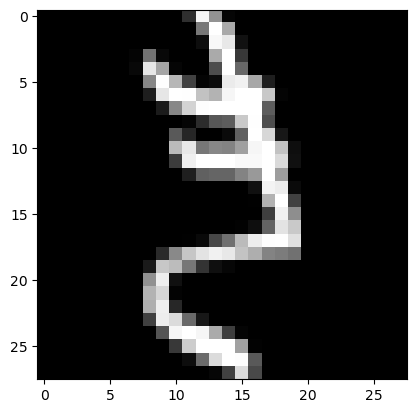

1
き


In [7]:
plt.imshow(X_train[423], cmap=plt.cm.gray)
plt.show()
print(y_train[423])
print(labelindex[1])


## データ前処理 

どんなデータになっているのか確認

[[  0   0 133  91   7]
 [  0   0 128 128  20]
 [  0   0  95 224  20]
 [  0   0 112 159  64]
 [  0   1 211 234 253]]


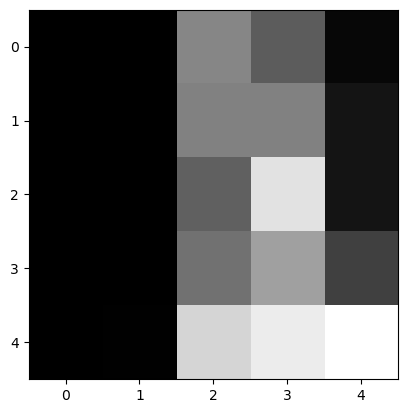

In [8]:
print(X_train[0,10:15,10:15])
plt.imshow(X_train[0,10:15,10:15], cmap = plt.cm.gray)
plt.show()

最大値の255で割ることでnormalizeし、0-1のレンジに変換

In [9]:
# 訓練/テストデータの正規化
X_train = X_train / 255 
X_test = X_test/ 255

[[0.         0.         0.52156863 0.35686275 0.02745098]
 [0.         0.         0.50196078 0.50196078 0.07843137]
 [0.         0.         0.37254902 0.87843137 0.07843137]
 [0.         0.         0.43921569 0.62352941 0.25098039]
 [0.         0.00392157 0.82745098 0.91764706 0.99215686]]


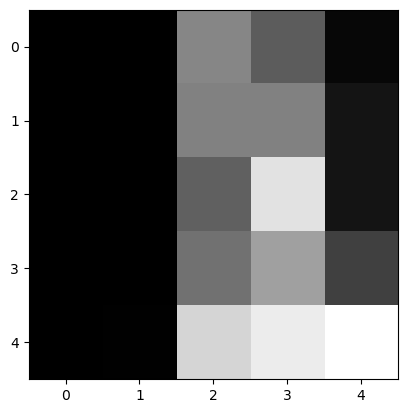

In [10]:
print(X_train[0,10:15,10:15])
plt.imshow(X_train[0,10:15,10:15], cmap = plt.cm.gray)
plt.show()

続いてLightGBMでモデル訓練を行うため、訓練・テストデータのサイズを変更します。現在は(レコード数, 縦, 横)の形です。28 x 28 = 784ですので、(レコード数, 784)へ変更します。

In [11]:
print(X_train.shape)
print(X_test.shape)


(60000, 28, 28)
(10000, 28, 28)


In [12]:
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)
print(X_train.shape)
print(X_test.shape)



(60000, 784)
(10000, 784)


In [13]:
print(X_train[0])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.03921569 0.02745098 0.91372549 0.3372549
 0.         0.         0.1254902  0.38823529 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.21176471 1.         0.32941176 0.         0.
 0.02745098 0.59215686 0.0745098  0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.59607843
 0.98431373 0.05490196 0.         0.         0.09803922 0.60784314
 0.38431373 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.50588235 0.97254902 0.7372549  0.
 0.         0.         0.31372549

##### ハイパーパラメータ


In [ ]:
lgb.LGBMClassifier()

# ブラウザのjupyterじゃないと表示されない
'''
LGBMClassifier(
    boosting_type='gbdt', 
    class_weight=None, 
    colsample_bytree=1.0,
    importance_type='split', 
    learning_rate=0.1, 
    max_depth=-1,
    min_child_samples=20, 
    min_child_weight=0.001, 
    min_split_gain=0.0,
    n_estimators=100, 
    n_jobs=-1, 
    num_leaves=31, 
    objective=None,
    random_state=None, 
    reg_alpha=0.0, 
    reg_lambda=0.0, 
    silent=True,
    subsample=1.0, 
    subsample_for_bin=200000, 
    subsample_freq=0
    )
'''

LGBMClassifier()

# LightGBMモデル訓練

In [15]:
# 訓練・テストデータの設定
train_data = lgb.Dataset(X_train, label=y_train)
eval_data = lgb.Dataset(X_test, label=y_test, reference= train_data)


In [16]:
params = {
'task': 'train',
'boosting_type': 'gbdt',
'objective': 'multiclass',
'num_class': 10,
'verbose': 5,
}


In [17]:
gbm = lgb.train(
    params,
    train_data,
    valid_sets=eval_data,
    num_boost_round=100,
    # verbose_eval=5
    )

[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.782756
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.671165
[LightGBM] [Debug] init for col-wise cost 0.083936 seconds, init for row-wise cost 0.190084 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.107869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 170893
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 784
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info]

# 予測

In [19]:
preds = gbm.predict(X_test)
print(preds[0])
y_pred = []
for x in preds:
    y_pred.append(np.argmax(x))
print('number of y_pred is ' + str(len(y_pred)))
print(y_pred[0:5])
confusion_matrix(y_test, y_pred)

[1.39718938e-04 5.51595529e-03 9.67645583e-01 2.41531244e-04
 3.60542460e-03 1.18938347e-02 5.29109666e-03 4.14806148e-04
 4.05319520e-03 1.19885421e-03]
number of y_pred is 10000
[2, 1, 3, 1, 3]


array([[900,   2,   4,   4,  28,   8,   5,  28,  19,   2],
       [  1, 869,  26,   2,  16,   6,  41,   7,  15,  17],
       [ 10,  15, 852,  48,  12,   5,  23,  11,  14,  10],
       [  2,   9,  30, 936,   6,   3,   6,   3,   1,   4],
       [ 25,  15,  24,   9, 863,   6,  26,   8,  14,  10],
       [  6,  20,  77,   6,  14, 835,  30,   2,   6,   4],
       [  2,   9,  37,   5,  15,   6, 916,   6,   2,   2],
       [  8,   8,  16,   3,  49,   1,  35, 830,  33,  17],
       [  3,  25,  10,  26,   0,   6,  15,   3, 907,   5],
       [  6,  21,  21,   6,  35,   0,   8,  17,  17, 869]])

In [20]:
np.sum(confusion_matrix(y_test, y_pred))
# confusion matrixの総和はy_predの総和に等しい。
# つまり、どの文字をどの文字として予測したかに対応した行列になっている。
# 0を0と予測できた数は900, 0を1と予測した数が2(反対かも)のような行列

10000

正解率

In [21]:
accuracy_score(y_test, y_pred)

0.8777

各サンプルの答え確認

In [22]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 784)
(10000, 784)
(60000,)
(10000,)


In [23]:
X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.03921569, 0.02745098,
       0.91372549, 0.3372549 , 0.        , 0.        , 0.1254902 ,
       0.38823529, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.21176471, 1.        , 0.32941176,
       0.        , 0.        , 0.02745098, 0.59215686, 0.0745098 ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.59607843, 0.98431373, 0.05490196, 0.        , 0.        ,
       0.09803922, 0.60784314, 0.38431373, 0.        , 0.     

3
正解の文字は "つ"
3
予測した文字は "つ"


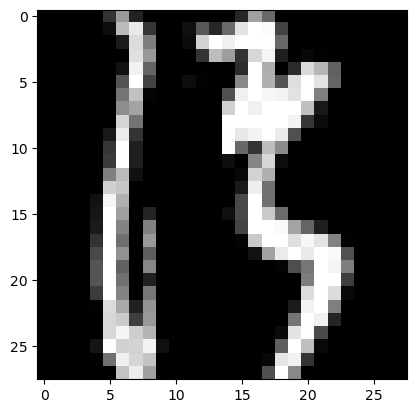

In [25]:
n_y_test = 12
print(y_test[n_y_test])
print('正解の文字は "'+labelindex[y_test[n_y_test]]+'"')
print(y_pred[n_y_test])
print('予測した文字は "'+labelindex[y_pred[n_y_test]]+'"')
plt.imshow(X_test[n_y_test].reshape(28,28), cmap=plt.cm.gray)
plt.show()


予測確認

In [26]:
# 1,-1でreshapeすると、x=yの形でreshapeされる
X_test[0].reshape(1,-1)
X_test[0].reshape(28,28)


array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.38431373, 0.18039216, 0.01960784, 0.37647059,
        0.52156863, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.58823529, 0.80392157, 0.8627451 , 1.        ,
        0.98431373, 0.45882353, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.29803922, 0.86666667, 0.95686275, 1.        ,
        0.95294118, 0.2666

In [29]:
test = 4
# 試しにtraining dataを代入してみると、10個のarray dataが出力された。
# これは、各文字列についての確率を予測した結果。つまり、もっとも確率の高いindexが予測結果となる。

# array dataの総和を計算
print(np.sum(gbm.predict(X_test[test].reshape(1,-1))))

# 予測結果のarray dataを出力
gbm.predict(X_test[test].reshape(1,-1))

0.9999999999999999


array([[2.14329754e-05, 3.76516415e-06, 5.25421892e-06, 9.99209975e-01,
        2.10261267e-05, 6.50686719e-04, 1.82737725e-05, 4.15189853e-05,
        5.09634370e-06, 2.29702058e-05]])

In [30]:
test = 1
gbm.predict(X_test[test].reshape(1,-1))
print(np.argmax(gbm.predict(X_test[test].reshape(1,-1))))
print('正解の文字は "'+labelindex[y_test[n_y_test]]+'"')
print('予測の文字は "'+labelindex[y_test[n_y_test]]+'"')


1
正解の文字は "つ"
予測の文字は "つ"


# BCL2のデータを予測してみる

https://www.ebi.ac.uk/chembl/explore/assays/STATE_ID:E0Iql66eksTYQjnqWPUTDQ%3D%3D


## データの前処理

### データのロード

#### load csv

In [62]:
import pandas as pd
df = pd.read_csv('./chembl/bcl2.csv', sep=';')
df.columns

Index(['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase',
       'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key',
       'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value',
       'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment',
       'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE',
       'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate',
       'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID',
       'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID',
       'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction',
       'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type',
       'Document ChEMBL ID', 'Source ID', 'Source Description',
       'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties',
       'Action Type', 'Standard Text Value'],
 

#### fetch from ChEMBL

In [6]:
# import libraries
# https://github.com/chembl/notebooks/blob/main/ChEMBL_webresource_client_examples.ipynb
from chembl_webresource_client.new_client import new_client
import chembl_webresource_client
import pandas as pd
print(f'pandas version: {pd.__version__}')
print(f'chembl_webresource_client version: {chembl_webresource_client.__version__}')

pandas version: 2.2.3
chembl_webresource_client version: 0.10.9


In [ ]:
# output target chembl id from uniprot id
uniprot_id = 'P29597'
target = new_client.target.get(
    target_components__accession=uniprot_id
    ).only(
        'target_chembl_id', 
        'organism', 
        'pref_name', 
        'target_type'
        )
df = pd.DataFrame.from_records(target)
df

,organism,pref_name,target_chembl_id,target_type
0,Homo sapiens,Tyrosine-protein kinase TYK2,CHEMBL3553,SINGLE PROTEIN
1,Homo sapiens,Tyrosine-protein kinase TYK2,CHEMBL3553,SINGLE PROTEIN
2,Homo sapiens,Janus Kinase (JAK),CHEMBL2363062,PROTEIN FAMILY
3,Homo sapiens,JAK1/JAK2/TYK2,CHEMBL3301390,PROTEIN COMPLEX
4,Homo sapiens,JAK1/TYK2,CHEMBL3301391,PROTEIN COMPLEX
5,Homo sapiens,JAK2/TYK2,CHEMBL3301392,PROTEIN COMPLEX


##### ChEMBL IDをindexで選んでデータを取得する

In [107]:
idx = input('Select the index of the target: ')
ChEMBL_id = df['target_chembl_id'][int(idx)]

activities = new_client.activity.filter(
    target_chembl_id__in=ChEMBL_id,  ##Specify a list of example targets
    pchembl_value__gte=5,  ##Specify a minimum threshold of the pChEMBL activity value. Note that pCHEMBL = -log10(IC50, XC50, AC50, Ki, Kd, potency). Greater than or equal to 5 (10um) is a typical minimum rule of thumb for binding activity between a compound and a protein target. 
    assay_type='B',  ##Only look for Binding Assays
).only([
    'molecule_chembl_id',
    'molecule_pref_name',
    'target_chembl_id',
    'target_pref_name',
    'parent_molecule_chembl_id',
    'pchembl_value',
    'canonical_smiles',
    'assay_description',
    'document_chembl_id',
    'document_journal',
    'document_year',
])
df = pd.DataFrame.from_records(activities).rename(columns={'canonical_smiles': 'Smiles', 'pchembl_value': 'pChEMBL Value', 'molecule_pref_name': 'Molecule Name'})
df['pChEMBL Value'] = df['pChEMBL Value'].astype(float)

df

,assay_description,Smiles,document_chembl_id,document_journal,document_year,molecule_chembl_id,Molecule Name,parent_molecule_chembl_id,pChEMBL Value,target_chembl_id,target_pref_name,value
0,Inhibition of Tyrosine kinase 2 kinase,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,CHEMBL1135866,Bioorg Med Chem Lett,2002,CHEMBL21156,None,CHEMBL21156,9.00,CHEMBL3553,Tyrosine-protein kinase TYK2,0.001
1,Inhibition of Tyrosine kinase 2 kinase,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,CHEMBL1135866,Bioorg Med Chem Lett,2002,CHEMBL21156,None,CHEMBL21156,9.00,CHEMBL3553,Tyrosine-protein kinase TYK2,0.001
2,Inhibition of Tyk2 by HTRF kinase assay,CNc1ncc2cc(-c3cc(C(=O)Nc4cc(C(F)(F)F)ccc4OC4CC...,CHEMBL1149344,J Med Chem,2006,CHEMBL386661,None,CHEMBL386661,5.56,CHEMBL3553,Tyrosine-protein kinase TYK2,2.73
3,Inhibition of Tyk2 by HTRF kinase assay,Cc1ccc(C(=O)Nc2cccc(C(F)(F)F)c2)cc1-c1ccc2nc(N...,CHEMBL1149344,J Med Chem,2006,CHEMBL215943,None,CHEMBL215943,5.74,CHEMBL3553,Tyrosine-protein kinase TYK2,1.83
4,Inhibition of Tyk2 by HTRF assay,Cc1cccc(C)c1-n1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)c...,CHEMBL1143254,J Med Chem,2008,CHEMBL410295,None,CHEMBL410295,5.92,CHEMBL3553,Tyrosine-protein kinase TYK2,1.2
...,...,...,...,...,...,...,...,...,...,...,...,...
2343,Selectivity interaction (HTRF activity assay) ...,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...,CHEMBL5465560,None,2024,CHEMBL3622821,UPADACITINIB,CHEMBL3622821,7.26,CHEMBL3553,Tyrosine-protein kinase TYK2,0.055
2344,Selectivity interaction (HTRF activity assay) ...,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...,CHEMBL5465560,None,2024,CHEMBL3622821,UPADACITINIB,CHEMBL3622821,5.33,CHEMBL3553,Tyrosine-protein kinase TYK2,4.7
2345,Selectivity interaction (Biochemical assay) EU...,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...,CHEMBL5465560,None,2024,CHEMBL3622821,UPADACITINIB,CHEMBL3622821,5.33,CHEMBL3553,Tyrosine-protein kinase TYK2,4690.0
2346,Selectivity interaction (Kinase panel (cellula...,CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC)cc(O...,CHEMBL5465560,None,2024,CHEMBL1852688,INFIGRATINIB,CHEMBL1852688,5.48,CHEMBL3553,Tyrosine-protein kinase TYK2,3303.0


##### データの分布を確認

In [108]:
# Smilesのカラムにnullがないかを確認
df.loc[df['Smiles'].isnull(), :]

,assay_description,Smiles,document_chembl_id,document_journal,document_year,molecule_chembl_id,Molecule Name,parent_molecule_chembl_id,pChEMBL Value,target_chembl_id,target_pref_name,value


In [109]:
# IC50のカラムにnullがないかを確認
df.loc[df['pChEMBL Value'].isnull(), :]

,assay_description,Smiles,document_chembl_id,document_journal,document_year,molecule_chembl_id,Molecule Name,parent_molecule_chembl_id,pChEMBL Value,target_chembl_id,target_pref_name,value


In [110]:
# SmilesとIC50値, pChEMBL Valueの表を作成
extracted_cols = ['Molecule Name', 'Smiles', 'pChEMBL Value']
df_mols = df[extracted_cols].rename(columns={'pChEMBL Value': 'pIC50'})
df_mols.head()

,Molecule Name,Smiles,pIC50
0,None,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,9.00
1,None,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,9.00
2,None,CNc1ncc2cc(-c3cc(C(=O)Nc4cc(C(F)(F)F)ccc4OC4CC...,5.56
3,None,Cc1ccc(C(=O)Nc2cccc(C(F)(F)F)c2)cc1-c1ccc2nc(N...,5.74
4,None,Cc1cccc(C)c1-n1c(=O)c2cnc(Nc3ccc(N4CCN(C)CC4)c...,5.92


In [111]:
# IC50値の要約統計量を表示
df_mols.describe().round(2)  

,pIC50
count,2348.00
mean,7.19
std,1.13
min,5.00
25%,6.40
50%,7.03
75%,7.85
max,11.00


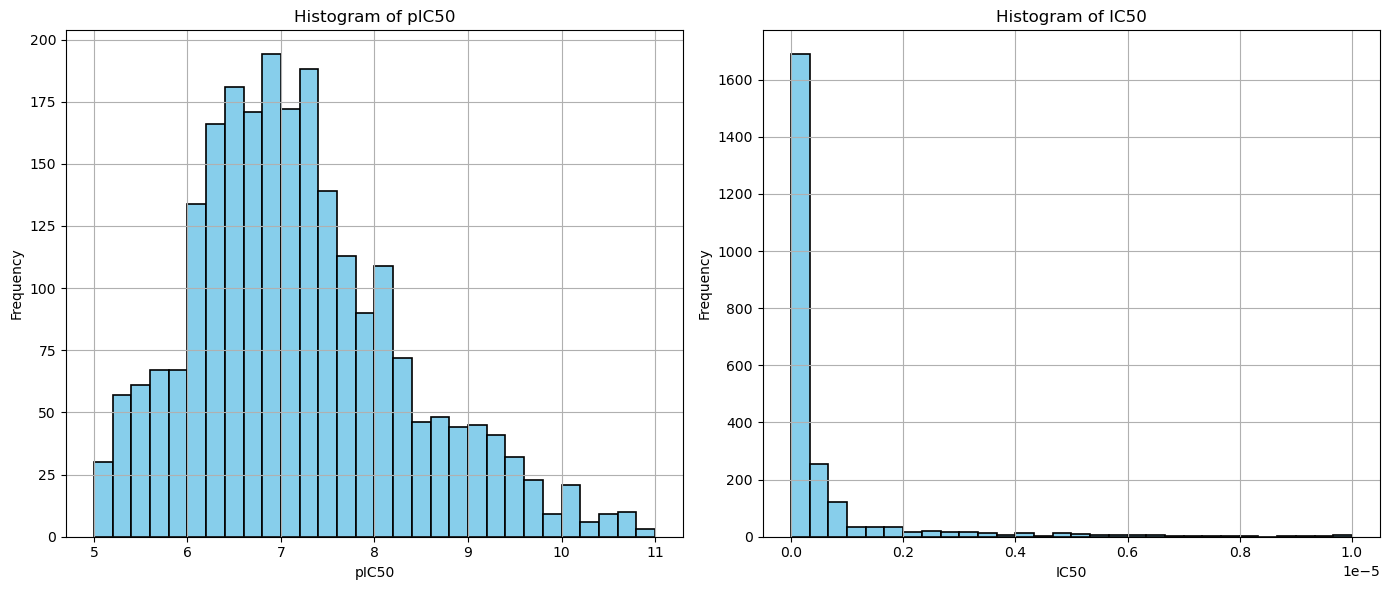

In [112]:
# データの分布を表示
import matplotlib.pyplot as plt
import pandas as pd

# pIC50をIC50に変換する関数
def pIC50_to_IC50(pIC50):
    return 10**(-pIC50)

# IC50の計算
df_mols['IC50'] = df_mols['pIC50'].apply(pIC50_to_IC50)

# ヒストグラムを並べて表示
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# pIC50のヒストグラム
axes[0].hist(df_mols['pIC50'], bins=30, edgecolor='black', color='skyblue', linewidth=1.2)
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of pIC50')
axes[0].grid(True)

# IC50のヒストグラム
axes[1].hist(df_mols['IC50'], bins=30, edgecolor='black', color='skyblue', linewidth=1.2)
axes[1].set_xlabel('IC50')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of IC50')
axes[1].grid(True)

plt.tight_layout()
plt.show()


### SMILES文字列の分子構造正規化・重複確認

#### 正規化

In [ ]:
from rdkit import Chem  # RDKit から `Chem` というモジュールをインポートする
from rdkit import RDLogger
from rdkit.Chem.MolStandardize import rdMolStandardize

log = RDLogger.logger()
log.setLevel(RDLogger.CRITICAL)  # RDKitでの操作の際に Warning を表示しないようにする

# 前処理用の関数を定義
def preprocess_smiles(smi):
    mol = Chem.MolFromSmiles(smi)  # SMILES文字列の読み込み
    mol = rdMolStandardize.FragmentParent(mol)  # 読み込んだ分子構造の前処理
    return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)  # 立体化学の情報を保持し、正規化されたSMILES文字列を出力
df_mols["ModSmiles"] = df_mols["Smiles"].map(preprocess_smiles)  # preprocess_smiles 関数を df_mols の "Smiles" 列に適用
df_mols[df_mols["ModSmiles"] != df_mols["Smiles"]]  # SMILES文字列の修正前後で変更があったものを表示

#### 重複の確認

In [101]:
print(f'ユニークなSMILES/dfに含まれるSMILES: {len(df_mols['ModSmiles'].unique())}/{len(df_mols)}') 

ユニークなSMILES/dfに含まれるSMILES: 1840/2348


In [102]:
# "ModSmiles" が別のエントリと重複しているエントリを抽出
df_mols[df_mols.duplicated(keep=False, subset="ModSmiles")]  

,Molecule Name,Smiles,pIC50,IC50,ModSmiles
0,None,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,4.38,4.168694e-05,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1
1,None,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,5.80,1.584893e-06,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1
5,None,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,6.96,1.096478e-07,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1
6,TAE-684,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,7.16,6.918310e-08,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...
7,AT-9283,O=C(Nc1c[nH]nc1-c1nc2ccc(CN3CCOCC3)cc2[nH]1)NC...,8.00,1.000000e-08,O=C(Nc1c[nH]nc1-c1nc2ccc(CN3CCOCC3)cc2[nH]1)NC...
...,...,...,...,...,...
2343,UPADACITINIB,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...,5.76,1.737801e-06,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...
2344,UPADACITINIB,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...,6.59,2.570396e-07,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...
2345,UPADACITINIB,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...,6.28,5.248075e-07,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...
2346,INFIGRATINIB,CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC)cc(O...,5.81,1.548817e-06,CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC)cc(O...


In [103]:
# 平均値で重複を除去
df_mols = (df_mols.groupby("ModSmiles", as_index=False).mean(numeric_only=True)  # "ModSmiles" の内容で分けたグループについて値の平均をとる
                  .rename(columns={"ModSmiles": "Smiles"}))  # 列名の変更
df_mols

,Smiles,pIC50,IC50
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,6.530000,2.951209e-07
1,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,8.430000,3.715352e-09
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,6.330000,4.677351e-07
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,8.290000,5.128614e-09
4,Brc1ncc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,6.140000,7.244360e-07
...,...,...,...
1835,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,6.200000,6.309573e-07
1836,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,5.920000,1.202264e-06
1837,c1nc(-c2cn(CC3CO3)nn2)c2cc[nH]c2n1,7.223333,4.218239e-07
1838,c1nc(CCNC[C@H]2CC[C@H](c3nnn4cnc5[nH]ccc5c34)C...,10.480000,3.311311e-11


### 処理したデータを保存

In [ ]:
df_mols.to_csv("./chembl/prop.csv", index=False)  # 保存するファイル名を指定。indexは出力しないようにする。

## 予測モデルの訓練と評価

### データのロードと記述子計算

In [ ]:
import pandas as pd
df = pd.read_csv('./chembl/prop.csv')  # csvデータの読み込み
print('{} entries'.format(len(df))) # データセットないのエントリ数を表示
df.head()

1949 entries


,Smiles,pIC50
0,Brc1cccc[n+]1-c1ccc2cc(-[n+]3ccccc3Br)ccc2c1,4.931814
1,C#CCCOC(=O)Nc1ccc(C2=NN(C(=O)c3ccc(Br)cc3)C(c3...,7.187087
2,C#CCN(C)CC[C@H](CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(...,5.886057
3,C#Cc1cc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc...,8.343902
4,C#Cc1cc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc...,8.936667


In [18]:
from rdkit.Chem import PandasTools  # RDKit の PandasTools をインポート

# df に対し、"Smiles" 列に記載されたSMILES文字列から分子構造データを作成し、結果を "Mol" カラムに書き出す
PandasTools.AddMoleculeColumnToFrame(df, smilesCol="Smiles", molCol="Mol")
df.head()

,Smiles,pIC50,Mol
0,Brc1cccc[n+]1-c1ccc2cc(-[n+]3ccccc3Br)ccc2c1,4.931814,<rdkit.Chem.rdchem.Mol object at 0x12d28f5a0>
1,C#CCCOC(=O)Nc1ccc(C2=NN(C(=O)c3ccc(Br)cc3)C(c3...,7.187087,<rdkit.Chem.rdchem.Mol object at 0x12fd98f20>
2,C#CCN(C)CC[C@H](CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(...,5.886057,<rdkit.Chem.rdchem.Mol object at 0x12fd98f90>
3,C#Cc1cc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc...,8.343902,<rdkit.Chem.rdchem.Mol object at 0x12fdc2420>
4,C#Cc1cc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc...,8.936667,<rdkit.Chem.rdchem.Mol object at 0x12fdc1e00>


In [19]:
# descriptorを計算してdfに追加
from rdkit.Chem import Descriptors

desc_names = sorted([d for d, _ in Descriptors.descList]) # 全記述子の名称のリストを取得 (順序を固定するため辞書順にソートしておく)
print(f"{len(desc_names)} descriptors")
print(desc_names)

from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator

# desc_namesに含まれている記述子を計算するインスタンスを準備
calc = MolecularDescriptorCalculator(desc_names)

# calc の CalcDescriptorsメソッドを各分子に適用して記述子計算
descs = [calc.CalcDescriptors(m) for m in df["Mol"]]

df_desc = pd.DataFrame(descs, columns=desc_names)  # 計算結果をデータフレームにまとめる
df = pd.concat([df, df_desc], axis=1)  # df_desc を df に (右から) 結合
df.head()

210 descriptors
['AvgIpc', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'ExactMolWt', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'FractionCSP3', 'HallKierAlpha', 'HeavyAtomCount', 'HeavyAtomMolWt', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'MaxAbsEStateIndex', 'MaxAbsPartialCharge', 'MaxEStateIndex', 'MaxPartialCharge', 'MinAbsEStateIndex', 'MinAbsPartialCharge', 'MinEStateIndex', 'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 'NHOHCount', 'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAroma

,Smiles,pIC50,Mol,AvgIpc,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,qed
0,Brc1cccc[n+]1-c1ccc2cc(-[n+]3ccccc3Br)ccc2c1,4.931814,<rdkit.Chem.rdchem.Mol object at 0x12d28f5a0>,2.616458,2.135845,-2.027567,2.196472,-2.315401,9.103187,-0.607519,...,0,0,0,0,0,0,0,0,0,0.307875
1,C#CCCOC(=O)Nc1ccc(C2=NN(C(=O)c3ccc(Br)cc3)C(c3...,7.187087,<rdkit.Chem.rdchem.Mol object at 0x12fd98f20>,3.307014,2.331487,-2.217430,2.338602,-2.265765,9.103001,0.071085,...,0,0,1,0,0,0,0,0,0,0.322256
2,C#CCN(C)CC[C@H](CSc1ccccc1)Nc1ccc(S(=O)(=O)NC(...,5.886057,<rdkit.Chem.rdchem.Mol object at 0x12fd98f90>,3.087118,2.482681,-2.242180,2.367886,-2.322699,7.989788,-0.043548,...,1,1,1,0,0,0,0,0,0,0.062592
3,C#Cc1cc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc...,8.343902,<rdkit.Chem.rdchem.Mol object at 0x12fdc2420>,3.709282,2.303020,-2.390943,2.434119,-2.468307,7.897012,0.048960,...,1,0,1,0,0,0,0,0,0,0.118429
4,C#Cc1cc(S(=O)(=O)NC(=O)c2ccc(N3CCN(CC4=C(c5ccc...,8.936667,<rdkit.Chem.rdchem.Mol object at 0x12fdc1e00>,3.722001,2.301623,-2.390923,2.433231,-2.468302,7.897011,0.048960,...,1,0,1,0,0,0,0,0,0,0.118546


In [20]:
# 分子構造によっては計算が失敗するので、NaNやinfを除去
import numpy as np  # NumPy のインポート

n_nulls = (df.replace(np.inf, np.nan)  # inf を NaN に置換した DataFrame を作成
             .isnull()  # 各要素が np.nan であるか否かを判定した DataFrame を作成
             .sum())  # 各列に含まれる np.nan の個数を計算
null_cols = []
for col, val in zip(df.columns, n_nulls):
    if val > 0:  # NaN や inf が含まれている
        null_cols.append(col)
print(f"{len(null_cols)} descriptors have missing values.")
print(null_cols)  # NaN や inf が含まれている列名のリストを表示

0 descriptors have missing values.
[]


In [21]:
# 失敗した記述子確認
indices_with_null = df[null_cols].isnull().any(axis=1)  # 行方向 (axis=1) に一つでも True があるエントリのインデックスを取得
df.loc[indices_with_null, ["Smiles", "pIC50"]]

,Smiles,pIC50


### データの分割と訓練

In [22]:
### データセットの分割
from sklearn.model_selection import train_test_split

# テストデータセットの比率を全体の2割に設定 (再現性を保証するため、乱数シードを固定している)
train_valid_df, test_df = train_test_split(df, test_size=0.2, random_state=0)

print(f"#Training + Validation samples: {len(train_valid_df)}")
print(f"#Test samples: {len(test_df)}")

#Training + Validation samples: 1559
#Test samples: 390


In [36]:
import lightgbm as lgb
print(lgb.__version__)

# データの準備
train_data = lgb.Dataset(train_valid_df[desc_names], label=train_valid_df["pIC50"])
eval_data = lgb.Dataset(test_df[desc_names], label=test_df["pIC50"])

4.5.0


### ハイパーパラメータ設定と訓練

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22255
[LightGBM] [Info] Number of data points in the train set: 1559, number of used features: 177
[LightGBM] [Info] Start training from score 7.542923
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[89]	training's rmse: 0.349229	valid_0's rmse: 0.673186


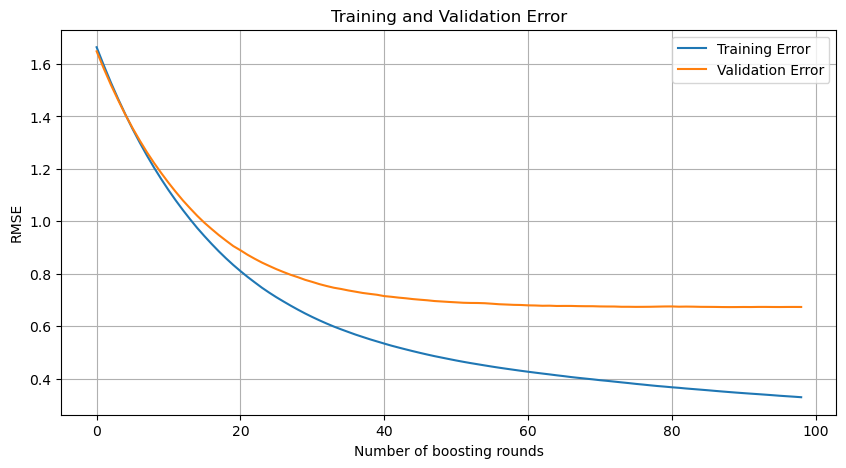

Best iteration: 89
Best score: defaultdict(<class 'collections.OrderedDict'>, {'training': OrderedDict({'rmse': 0.3492288145101005}), 'valid_0': OrderedDict({'rmse': 0.6731863402199001})})


In [49]:
import lightgbm as lgb
import matplotlib.pyplot as plt

# パラメータ設定
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'early_stopping_rounds': 10,
    'verbose': 1
}

# 結果を記録するコールバック関数
evals_result = {}
def record_evaluation(evals_result):
    def callback(env):
        if env.iteration == 0:
            evals_result['training'] = []
            evals_result['valid_0'] = []
        if len(env.evaluation_result_list) == 2:
            evals_result['training'].append(env.evaluation_result_list[0][2])
            evals_result['valid_0'].append(env.evaluation_result_list[1][2])
    return callback

# モデルのトレーニング
gbm = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, eval_data],
    valid_names=['training', 'valid_0'],
    num_boost_round=1000,
    callbacks=[record_evaluation(evals_result)]
)

# 訓練誤差と汎化誤差のグラフ化
def plot_learning_curve(evals_result):
    plt.figure(figsize=(10, 5))
    plt.plot(evals_result['training'], label='Training Error')
    plt.plot(evals_result['valid_0'], label='Validation Error')
    plt.xlabel('Number of boosting rounds')
    plt.ylabel('RMSE')
    plt.title('Training and Validation Error')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve(evals_result)

# Early stoppingの結果を表示
print(f"Best iteration: {gbm.best_iteration}")
print(f"Best score: {gbm.best_score}")


### 予測

In [45]:
# テストデータセットの出力
predictions = gbm.predict(
    test_df[desc_names], 
    num_iteration=gbm.best_iteration
    )
print(predictions)


[ 6.25959221  6.27179315  8.10042489  9.23007261  8.50233171  9.27120362
  9.52116171  5.38881699  6.2103144  10.08596022  6.13614424  6.28072024
  5.80150529  7.82142809  7.61292227  6.88610774  7.50690823  6.12798514
  7.18319621  5.40726748  8.21566025  5.36321594  5.64152133  9.19932047
  6.80748177  6.36537402  9.618997    4.86839049  4.95250794  7.62618761
  6.70760192  8.19784408  5.99885424  6.78926915 10.40713661 10.00926006
  8.50068546  5.64049193  8.26674978  5.92385099  5.84655167  6.92851813
  6.0801162  10.16481094 10.10863099  5.8215318  10.01183487  5.54267163
  9.35348594  7.39526181  7.7893055   5.23755265  6.13650416  5.37153575
  8.59594285  5.53761112  5.76253699  8.06766794  9.0375193   7.27206147
  5.85136822  7.93873735  8.86771055  6.81189096  6.66161052  6.01167784
  5.6665817   5.51252663 10.14883192  5.51269944  8.13845237  5.42620078
  9.65009046  6.43987858  5.88822933  5.51545147  9.66805559  6.45558501
  6.6627015   9.91549993  6.26653887  7.95515488 10

In [46]:
# 個別データ
predictions = gbm.predict(
    test_df[desc_names].iloc[0], 
    num_iteration=gbm.best_iteration
    )
print(predictions)


[6.25959221]


/Users/keetane/opt/anaconda3/envs/code/lib/python3.12/site-packages/lightgbm/basic.py:1218: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


### 予測値vsテストデータ 比較

In [47]:
# 予測データを挿入
test_df['pred'] = gbm.predict(test_df[desc_names], num_iteration=gbm.best_iteration)
# カラムの順序を再設定 
columns = list(test_df.columns) 
columns.insert(2, columns.pop(columns.index('pred'))) 
test_df = test_df[columns]
test_df.head()

,Smiles,pIC50,pred,Mol,AvgIpc,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,qed
18,CC(=O)N[C@@H](Cc1ccccc1)C(=O)Nc1ccc(C(=O)NS(=O...,5.469800,6.259592,<rdkit.Chem.rdchem.Mol object at 0x12fdc2b20>,3.032972,2.243084,-2.176981,2.279560,-2.439279,7.989310,...,1,0,0,0,0,0,0,0,0,0.065090
1520,Cc1cc(OCCCc2c3n(c4c(-c5c(C)nn(C)c5C)c(Cl)ccc24...,6.011367,6.271793,<rdkit.Chem.rdchem.Mol object at 0x14dc30270>,3.671495,2.373848,-2.337714,2.454387,-2.422832,6.351320,...,0,0,0,0,0,0,0,0,0,0.159108
1437,Cc1c(C(=O)O)c(-c2cccc(N3CCN(c4ccc(NS(=O)(=O)c5...,7.554421,8.100425,<rdkit.Chem.rdchem.Mol object at 0x14dc2dd90>,3.619846,2.483235,-2.372562,2.410725,-2.460998,7.989796,...,1,1,0,0,0,0,0,0,0,0.074602
187,CC1(C)CCC(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC...,9.757792,9.230073,<rdkit.Chem.rdchem.Mol object at 0x14dc0b5a0>,3.800098,2.366601,-2.391098,2.445818,-2.468313,7.897112,...,1,0,0,0,0,0,0,0,0,0.076022
333,CC1(C)CCC(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NN...,8.787546,8.502332,<rdkit.Chem.rdchem.Mol object at 0x14dc0f610>,3.750605,2.316454,-2.390925,2.434266,-2.511433,7.897109,...,1,0,0,0,0,0,0,0,0,0.079457


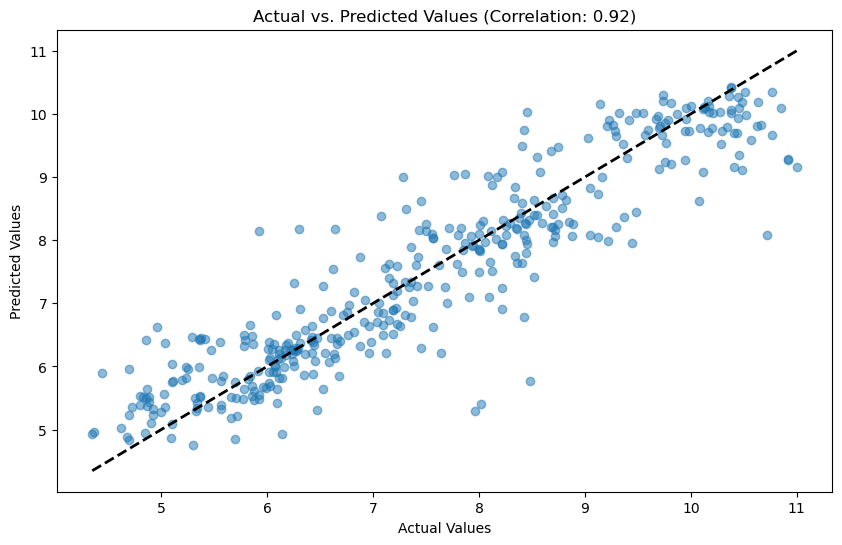

In [48]:
# plot
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# 実測値と予測値の取得
actual_values = test_df["pIC50"]
predicted_values = gbm.predict(test_df[desc_names], num_iteration=gbm.best_iteration)

# 相関係数の計算
correlation_coefficient, _ = pearsonr(actual_values, predicted_values)

# プロットの作成
plt.figure(figsize=(10, 6))
plt.scatter(actual_values, predicted_values, alpha=0.5)
plt.plot([actual_values.min(), actual_values.max()], [actual_values.min(), actual_values.max()], 'k--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs. Predicted Values (Correlation: {correlation_coefficient:.2f})')
plt.show()


### ハイパーパラメーターチューニング

In [146]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

# ハイパーパラメータの候補を設定
param_grid = {
    'num_leaves': [31, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# LGBMRegressorモデルのインスタンスを作成
model = lgb.LGBMRegressor()

# グリッドサーチを設定
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)

# グリッドサーチを実行
grid_search.fit(train_valid_df[desc_names], train_valid_df["pIC50"])

# 最適なパラメータの表示
print(f'Best parameters found: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_}')

# 最適なパラメータでモデルを再トレーニング
best_model = grid_search.best_estimator_
best_model.fit(train_valid_df[desc_names], train_valid_df["pIC50"])

# 予測
predictions = best_model.predict(test_df[desc_names])

print(predictions)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21915
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012993 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012992 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Number of data points in the train set: 1247, number of used features: 175
[LightGBM] [Info] Total Bins 21994
[LightGBM] [Info] Total Bins 21951
[LightGBM] [Info] Total Bi

KeyboardInterrupt: 

## デザイン化合物の予測

In [168]:
# SMILESの入力
import pandas as pd
input = pd.read_csv('./chembl/input.smi', delimiter='  ', header=None, names=['SMILES', 'Name'], engine='python')
input

,SMILES,Name
0,CC(C)C1=CC=CC=C1[C@@H]2CCCN2C3CC4(C3)CCN(CC4)C...,sonrotoclax
1,CC(C)C1=CC=CC=C1[C@@H]2CCCN2C3CC4(C3)CCN(CC4)C...,test
